# DATA 202 - Calvin University - Fall 2019
# Homework 2
Due: Thursday, September 19 @ 10pm

## Purpose
This assignment is designed to help you practice the following skills that are essential to your success as a data scientist:

* Technical
  * Construct several basic types of plots
* Communication
  * Use words to interpret plots.

This assignment will also help you become more familiar with the following content knowledge:

* Types of visual encodings of data


## Tasks

The instructions below will guide you through completing this assignment. A few strategic recommendations:

* Read through the whole thing before starting to get an overview
* Identify something that's unclear, or some knowledge you might be missing, and ask a question on Piazza.
* **Avoid** getting stuck on one part for a long time. Take breaks,.
* **Avoid** copying code off the Internet. Our coding will be cumulative, so get the practice: find the code on the Internet, write some notes to yourself about it if you need, then close the page and try to type it in using only your notes.

Before you begin, please fill out THIS GOOGLE FORM.

### INSTRUCTIONS

- To submit your assignment follow the instructions given in canvas.
- Restart the kernel and run the whole notebook again before you submit. 
- If you submit individually and you have worked with someone, please include the name of your [one] partner below. 
- As much as possible, try and stick to the hints and functions we import at the top of the homework, as those are the ideas and tools the class supports and is aiming to teach. And if a problem specifies a particular library you're required to use that library, and possibly others from the import list.

Names of people you have worked with goes here: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
plt.rcParams['figure.figsize'] = (16,8)
plt.rcParams['figure.dpi'] = 150
sns.set()

### Warm-Up Problem: Inferential Thinking

Consider the following scenario:

Only $1\%$ of 40-year-old women who participate in a routine mammography test have breast cancer. $80\%$ of women who have breast cancer will test positive, but $9.6\%$ of women who don’t have breast cancer will also get positive tests. 

Suppose we know that a woman of this age tested positive in a routine screening. What is the probability that she actually has breast cancer?

(No code, just math here. You don't have to use fancy formatting.)

**Hint:** Use Bayes' rule.



*Write your answer here, replacing this text.*

## Bike Sharing - Intro

You are hired by the administrators of the [Capital Bikeshare program](https://www.capitalbikeshare.com) program in Washington D.C., to **help them predict the hourly demand for rental bikes** and **give them suggestions on how to increase their revenue**. We will be working with this data over the next several homework assignments.

The predicted hourly demand could be used for planning the number of bikes that need to be available in the system at any given hour of the day. It costs the program money if bike stations are full and bikes cannot be returned, or empty and there are no bikes available. You will use multiple linear regression and polynomial regression and will explore techniques for subset selection to predict bike usage. Our eventual goal will be to build a regression model that can predict the total number of bike rentals in a given hour of the day, based on all the information we can get.

An example of a suggestion to increase revenue might be to offer discounts during certain times of the day either during holidays or non-holidays. Your suggestions will depend on your observations of the seasonality of ridership.

The data for this problem were collected from the Capital Bikeshare program over the course of two years (2011 and 2012).


In [13]:
hourly_counts = pd.read_csv('data/BSS_hour_raw.csv')
daily_counts = pd.read_csv('data/BSS_daily_agg.csv')

In [4]:
daily_counts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
dteday        731 non-null object
workingday    731 non-null int64
weather       731 non-null int64
casual        731 non-null int64
registered    731 non-null int64
dtypes: int64(4), object(1)
memory usage: 28.6+ KB


---
## 2: Exploring the Distribution of Riders

Let's begin by comparing the distribution of the daily counts of casual and registered riders.  

### Question 2
#### Question 2a

Use the [`sns.distplot`](https://seaborn.pydata.org/generated/seaborn.distplot.html) function to create a plot that overlays the distribution of the daily counts of `casual` and `registered` users. The temporal granularity of the records should be daily counts, which you should have after completing question 1c.

Include a legend, xlabel, ylabel, and title. Read the [seaborn plotting tutorial](https://seaborn.pydata.org/tutorial/distributions.html) if you're not sure how to add these. After creating the plot, look at it and make sure you understand what the plot is actually telling us, e.g on a given day, the most likely number of registered riders we expect is ~4000, but it could be anywhere from nearly 0 to 7000.

<img src='images/casual_v_registered.png' width="600px" />

<!--
BEGIN QUESTION
name: q2a
points: 2
manual: true
-->
<!-- EXPORT TO PDF -->

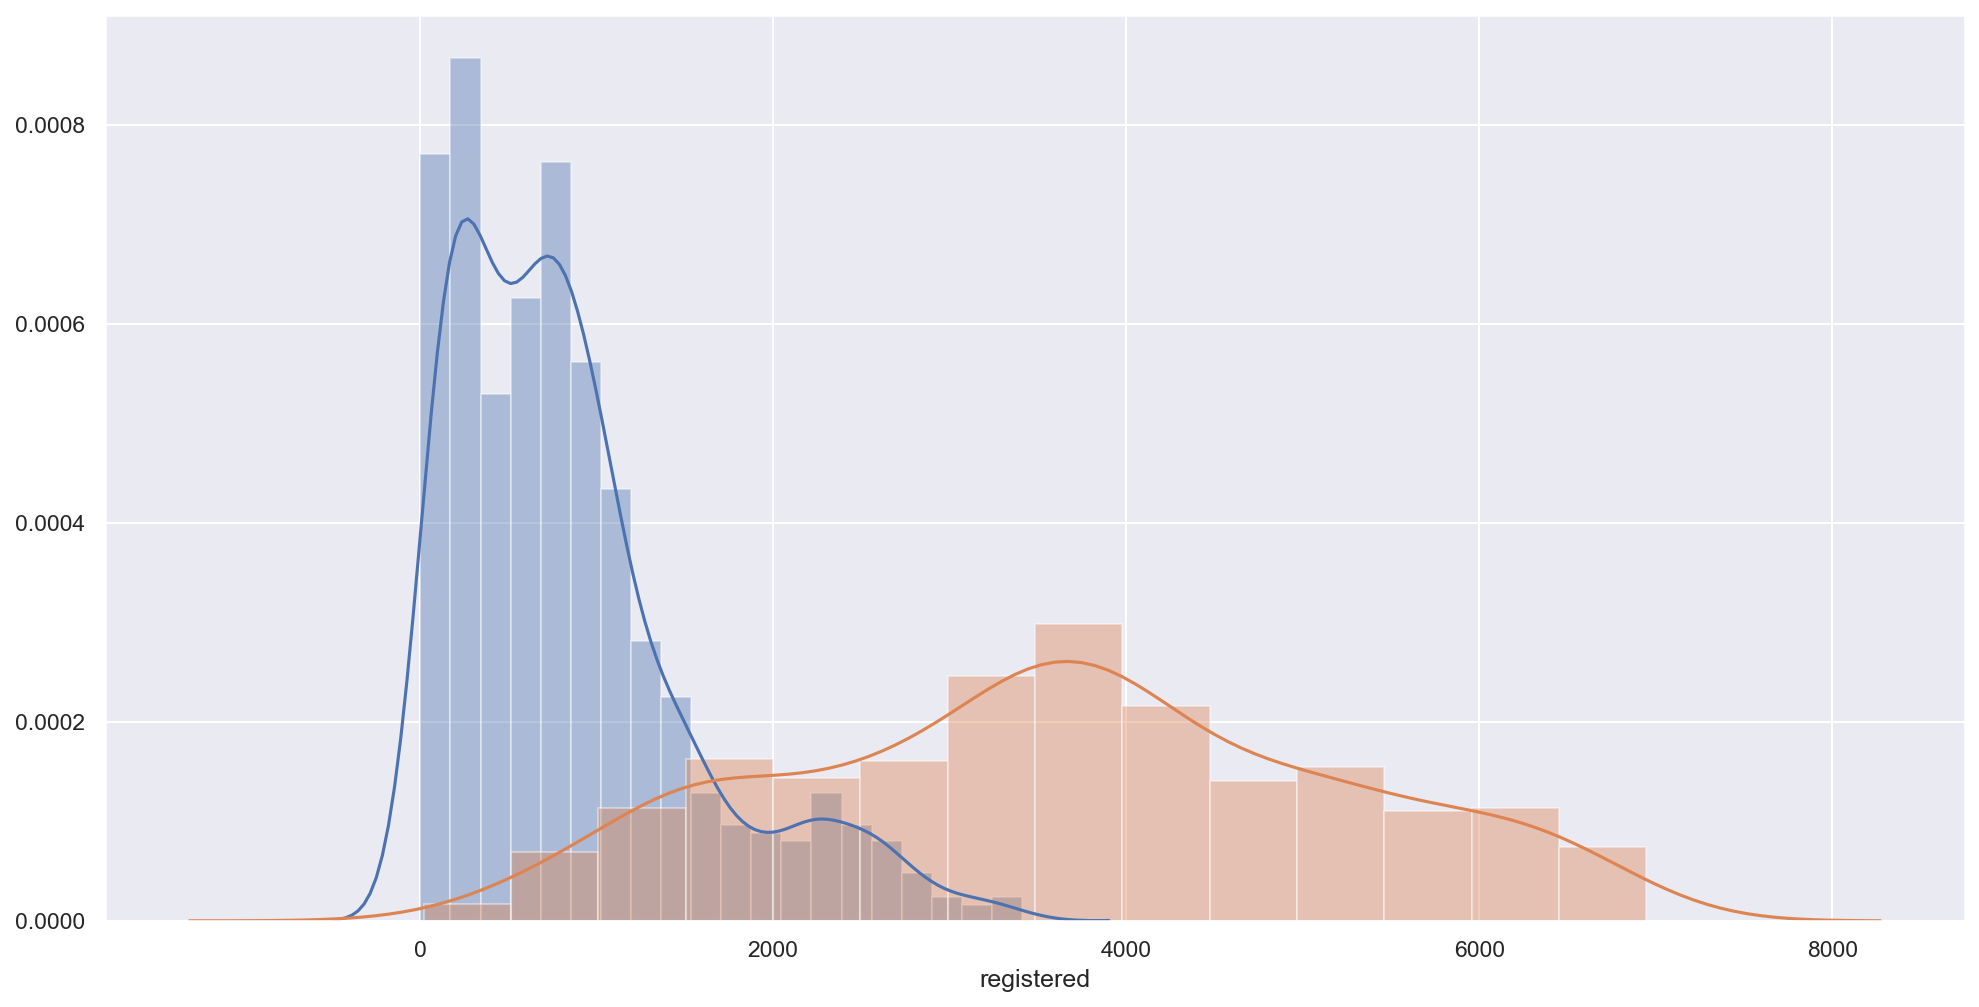

In [12]:
sns.distplot(daily_counts.casual)
sns.distplot(daily_counts.registered)

### Question 2b

In the cell below, descibe the differences you notice between the density curves for casual and registered riders.  Consider concepts such as modes, symmetry, skewness, tails, gaps and outliers.  Include a comment on the spread of the distributions. 
<!--
BEGIN QUESTION
name: q2b
points: 2
manual: true
-->
<!-- EXPORT TO PDF -->

*Write your answer here, replacing this text.*

## Ethical Considerations

City planners, transportation agencies, and policy makers have started to collaborate with bike sharing companies in order to reduce congestion and transportation costs. Recently city planners and policy makers have also been trying to make transportation more equitable. 

Equity in transportation includes: finding ways to make transportation more accessible to people in all neighborhoods within a given region, making the costs of transportation affordable to people across all income levels, and assessing how inclusive transportation systems are over time. Data about city residents may shed light on how to better assess transportation cost and equity impacts on transportation users. Bearing this in mind, answer the following two questions on the nature of the data, their possible shortcomings, and ethical considerations associated with how we as data scientists use, manipulate, and share this data.  

### Question 2c

In addition to the type of rider (casual vs. registered) and the overall count of each, what other kinds of demographic data would be useful (e.g. identity, neighborhood, monetary expenses, etc.)? 

*Write your answer here, replacing this text.*

### Question 2d

What is an example of a privacy or consent issue that could occur when accessing the demographic data you brought up in the previous question?

<!--
BEGIN QUESTION
name: q2d
points: 1
manual: true
-->
<!-- EXPORT TO PDF -->

*Write your answer here, replacing this text.*

### Question 2e

The density plots do not show us how the counts for registered and casual riders vary together. Use [`sns.lmplot`](https://seaborn.pydata.org/generated/seaborn.lmplot.html) to make a scatter plot to investigate the relationship between casual and registered counts. This time, let's use the `hourly_counts` DataFrame to plot hourly counts instead of daily counts.

The `lmplot` function will also try to draw a linear regression line (just as you saw in Data 8). Color the points in the scatterplot according to whether or not the day is working day. There are many points in the scatter plot so make them small to help reduce overplotting. Also make sure to set `fit_reg=True` to generate the linear regression line. You can set the `height` parameter if you want to adjust the size of the `lmplot`. Make sure to include a title.

<img src='images/casual_registered_working_nonworking.png' width="600px" />

**Hints:** 
* Checkout this helpful [tutorial on `lmplot`](https://seaborn.pydata.org/tutorial/regression.html).

* You will need to set `x`, `y`, and `hue` and the `scatter_kws`.

<!--
BEGIN QUESTION
name: q2e
points: 2
manual: true
-->
<!-- EXPORT TO PDF -->

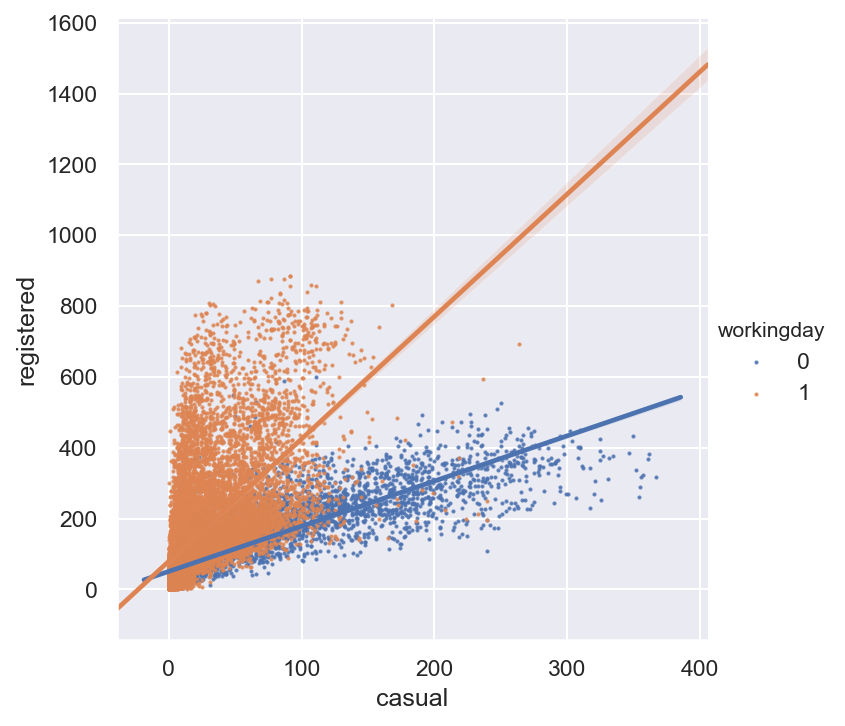

In [15]:
# Make the font size a bit bigger
sns.set(font_scale=1.)

# Your code here
sns.lmplot(x='casual', y='registered', hue='workingday', data=hourly_counts, scatter_kws={'s': 1})

### Question 2f

What does this scatterplot seem to reveal about the relationship (if any) between casual and registered riders and whether or not the day is on the weekend? What effect does [overplotting](http://www.textbook.ds100.org/ch/06/viz_principles_2.html) have on your ability to describe this relationship?

<!--
BEGIN QUESTION
name: q2f
points: 2
manual: true
-->
<!-- EXPORT TO PDF -->

*Write your answer here, replacing this text.*